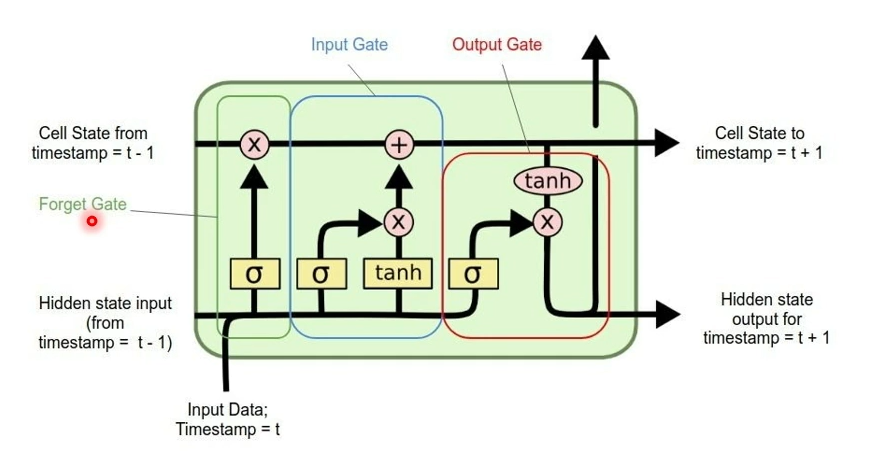

In [283]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter # words frequency
from itertools import product #grid search 

In [284]:
text = """Bu ürün beklentimi fazlasıyla karşıladı.
 Malzeme kalitesi gerçekten çok iyi. 
 Kargo hızlı ve sorunsuz bir şekilde elime ulaştı. 
 Fiyatına göre performansı harika. Kesinlikle tavsiye ederim ve öneririm !"""

In [285]:
words = text.replace(".", "").replace("!", "").lower().split()

In [286]:
words[:5]

['bu', 'ürün', 'beklentimi', 'fazlasıyla', 'karşıladı']

In [287]:
word_counts = Counter(words)

In [288]:
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
vocab

['ve',
 'bu',
 'ürün',
 'beklentimi',
 'fazlasıyla',
 'karşıladı',
 'malzeme',
 'kalitesi',
 'gerçekten',
 'çok',
 'iyi',
 'kargo',
 'hızlı',
 'sorunsuz',
 'bir',
 'şekilde',
 'elime',
 'ulaştı',
 'fiyatına',
 'göre',
 'performansı',
 'harika',
 'kesinlikle',
 'tavsiye',
 'ederim',
 'öneririm']

In [289]:
word_to_idx = {word: i for i, word in enumerate(vocab)}
idx_to_word = {i: word for i, word in enumerate(vocab)}
word_to_idx

{'ve': 0,
 'bu': 1,
 'ürün': 2,
 'beklentimi': 3,
 'fazlasıyla': 4,
 'karşıladı': 5,
 'malzeme': 6,
 'kalitesi': 7,
 'gerçekten': 8,
 'çok': 9,
 'iyi': 10,
 'kargo': 11,
 'hızlı': 12,
 'sorunsuz': 13,
 'bir': 14,
 'şekilde': 15,
 'elime': 16,
 'ulaştı': 17,
 'fiyatına': 18,
 'göre': 19,
 'performansı': 20,
 'harika': 21,
 'kesinlikle': 22,
 'tavsiye': 23,
 'ederim': 24,
 'öneririm': 25}

In [290]:
data = [(words[i], words[i+1]) for i in range(len(words) - 1)]

In [291]:
data

[('bu', 'ürün'),
 ('ürün', 'beklentimi'),
 ('beklentimi', 'fazlasıyla'),
 ('fazlasıyla', 'karşıladı'),
 ('karşıladı', 'malzeme'),
 ('malzeme', 'kalitesi'),
 ('kalitesi', 'gerçekten'),
 ('gerçekten', 'çok'),
 ('çok', 'iyi'),
 ('iyi', 'kargo'),
 ('kargo', 'hızlı'),
 ('hızlı', 've'),
 ('ve', 'sorunsuz'),
 ('sorunsuz', 'bir'),
 ('bir', 'şekilde'),
 ('şekilde', 'elime'),
 ('elime', 'ulaştı'),
 ('ulaştı', 'fiyatına'),
 ('fiyatına', 'göre'),
 ('göre', 'performansı'),
 ('performansı', 'harika'),
 ('harika', 'kesinlikle'),
 ('kesinlikle', 'tavsiye'),
 ('tavsiye', 'ederim'),
 ('ederim', 've'),
 ('ve', 'öneririm')]

In [292]:
class LSTM(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(LSTM, self).__init__()
        
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_size)
        self.fc = nn.Linear(in_features=hidden_size, out_features=vocab_size)

    def forward(self, x):
        
        x = self.embedding(x)
        lstm_out, _ = self.lstm(x.view(1,1,-1))
        output = self.fc(lstm_out.view(1,-1))

        return output


In [293]:
def prepare_squence(seq, to_idx):
    return torch.tensor([to_idx[w] for w in seq], dtype=torch.long)

In [294]:
embedding_size = [8, 16]
hidden_size = [32, 64]
learning_rate = [0.001, 0.005]

best_loss = float("inf")
best_params = {}


In [295]:
for emb_size, hdn_size, lr in product(embedding_size, hidden_size, learning_rate):
    model = LSTM(len(word_to_idx), emb_size, hdn_size) 
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr)

    for epoch in range(50):
        epoch_loss = 0
        for word, next_word in data:
            model.zero_grad()
            input_tensor = prepare_squence([word], word_to_idx)
            target_tensor = prepare_squence([next_word], word_to_idx)
          
            
            output = model(input_tensor)
            loss = loss_function(output, target_tensor)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if epoch % 10 == 0:
            print(f"Params: Emb={emb_size}, Hid={hdn_size}, LR={lr} | Epoch: {epoch}, Loss: {epoch_loss:.5f}")

    
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_params = {
            "embedding_dim": emb_size, 
            "hidden_dim": hdn_size, 
            "learning_rate": lr
        }

print("-" * 30)
print(f"Final Best Params: {best_params}")

Params: Emb=8, Hid=32, LR=0.001 | Epoch: 0, Loss: 84.78042
Params: Emb=8, Hid=32, LR=0.001 | Epoch: 10, Loss: 76.57242
Params: Emb=8, Hid=32, LR=0.001 | Epoch: 20, Loss: 56.87143
Params: Emb=8, Hid=32, LR=0.001 | Epoch: 30, Loss: 35.81977
Params: Emb=8, Hid=32, LR=0.001 | Epoch: 40, Loss: 21.59672
Params: Emb=8, Hid=32, LR=0.005 | Epoch: 0, Loss: 85.66073
Params: Emb=8, Hid=32, LR=0.005 | Epoch: 10, Loss: 16.40518
Params: Emb=8, Hid=32, LR=0.005 | Epoch: 20, Loss: 3.96329
Params: Emb=8, Hid=32, LR=0.005 | Epoch: 30, Loss: 2.56937
Params: Emb=8, Hid=32, LR=0.005 | Epoch: 40, Loss: 2.15408
Params: Emb=8, Hid=64, LR=0.001 | Epoch: 0, Loss: 85.20314
Params: Emb=8, Hid=64, LR=0.001 | Epoch: 10, Loss: 73.38987
Params: Emb=8, Hid=64, LR=0.001 | Epoch: 20, Loss: 40.33220
Params: Emb=8, Hid=64, LR=0.001 | Epoch: 30, Loss: 16.84732
Params: Emb=8, Hid=64, LR=0.001 | Epoch: 40, Loss: 8.14942
Params: Emb=8, Hid=64, LR=0.005 | Epoch: 0, Loss: 85.90893
Params: Emb=8, Hid=64, LR=0.005 | Epoch: 10, Los

In [296]:
final_model = LSTM(len(vocab), best_params['embedding_dim'], hidden_size=best_params['hidden_dim'])
optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'])
loss_function = nn.CrossEntropyLoss()
epochs = 100

In [297]:
for epoch in range(epochs):
    epoch_loss = 0
    for word, next_word in data:
        final_model.zero_grad()
        input_tensor = prepare_squence([word], word_to_idx)
        target_tensor = prepare_squence([next_word], word_to_idx)
        output = final_model(input_tensor)
        loss = loss_function(output, target_tensor)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {epoch_loss/len(data):.4f}")
    

Epoch: 0 | Loss: 3.2973
Epoch: 10 | Loss: 0.1418
Epoch: 20 | Loss: 0.0845
Epoch: 30 | Loss: 0.0744
Epoch: 40 | Loss: 0.0701
Epoch: 50 | Loss: 0.0676
Epoch: 60 | Loss: 0.0661
Epoch: 70 | Loss: 0.0647
Epoch: 80 | Loss: 0.0638
Epoch: 90 | Loss: 0.0634


In [298]:
def predict_sequence(start_word, num_words):
    current_word = start_word
    output_sequence = [current_word]


    for _ in range(num_words):
        with torch.no_grad():
            input_tensor = prepare_squence([current_word], word_to_idx)
            print(input_tensor)

            output = final_model(input_tensor)
            print(output)

            predicted_idx = torch.argmax(output).item()
            print(predicted_idx)

            predicted_word = idx_to_word[predicted_idx]
            print(predicted_word)
            
            output_sequence.append(predicted_word)
            current_word = predicted_word
            print("--------------------------------------------------------------------------")

    return output_sequence



In [302]:
start_word = "ve"
num_prediction = 3
predicted_sequence = predict_sequence(start_word, num_prediction)
print(predicted_sequence)

tensor([0])
tensor([[-2.3329, -3.3738, -2.8928, -2.2931, -2.0181, -1.1890, -1.5280, -2.0699,
         -1.1397, -1.9529, -2.2855, -1.7998, -2.0339,  5.0352, -1.7350, -2.2794,
         -2.4669, -2.5417, -1.4870, -1.6300, -1.7489, -1.3160, -1.8412, -4.1575,
         -1.7868,  4.8938]])
13
sorunsuz
--------------------------------------------------------------------------
tensor([13])
tensor([[ 1.7560, -1.5406, -6.5672, -3.4003, -2.5986,  0.9655, -1.8063,  0.5094,
         -1.7584, -2.4379, -1.1338,  1.4545, -1.6892,  0.5064, 11.2539, -4.8604,
          0.6109,  0.2729, -1.0157, -1.2833,  1.0834, -3.4480, -5.6284,  1.6606,
          1.2970,  0.4067]])
14
bir
--------------------------------------------------------------------------
tensor([14])
tensor([[ 1.8731, -0.6635,  1.1221,  2.4738, -0.6740, -0.9882,  0.5503, -0.5955,
         -1.7747, -0.0405,  0.5599,  2.6442, -1.4198, -1.8583, -3.5507, 12.0058,
          1.0557, -2.0993,  0.0160, -1.8398, -1.0247,  2.9074,  2.8477, -0.9197,
      

In [303]:
print(" ".join(predicted_sequence))

ve sorunsuz bir şekilde
